# Nonlinear Probing: Linear vs MLP and Cross-Condition Transfer

Tests whether the displacement observed in nb08/09 is a linear rotation
(MLP can recover the signal) or a deeper structural change (even MLP fails).

### Key questions
1. **Linear vs MLP gap** — Is there nonlinear harmfulness signal that
   direction-based defenses miss by design?
2. **Cross-condition transfer** — Can a probe trained on single-turn
   detect harmfulness in multi-turn? What about across extraction conditions?
3. **Per-turn stability** — Is the nonlinear representation stable across turns,
   even though the linear direction rotates?

### Analyses
1. Linear vs MLP AUROC per condition × layer (fast)
2. 3×3 cross-condition transfer matrix (medium)
3. Per-turn transfer heatmap: train at k, test at k' (slowest)

In [1]:
import json as _json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODEL     = 'llama'   # model subdirectory under data/

REPR_ROOT = repo_root / 'data' / MODEL / 'representations'
FIG_DIR   = repo_root / 'figures'

FRAMEWORKS = ['crescendo', 'actorattack', 'xteaming']
SPLITS     = ['harmful', 'benign']

# ── Load per-model layer sweep from layer_indices.json ──────────────────────
# After the down-select, saved arrays have shape (N, 8, D). layer_indices.json
# sits next to each (fw_split) directory with the original transformer-layer IDs.

def _load_layer_info(model_root):
    """Walk the representations tree; return the first layer_indices.json found."""
    for sub in ("trajectories", "nocontext", "single_turn"):
        root = model_root / sub
        if not root.exists():
            continue
        for d in root.iterdir():
            fp = d / "layer_indices.json"
            if fp.exists():
                return _json.loads(fp.read_text())
    raise FileNotFoundError(
        f"No layer_indices.json under {model_root} — run scripts/downselect_layers.py"
    )

_LAYER_INFO    = _load_layer_info(REPR_ROOT)
N_SAVED_LAYERS = _LAYER_INFO["n_sweep"]
VERIFY_LAYERS  = list(range(N_SAVED_LAYERS))           # positions into the saved (N, 8, D) arrays
VERIFY_LABELS  = _LAYER_INFO["labels"]                 # e.g. ["L1", "L5", "L9", ...]

print(f"Saved-layer sweep: {VERIFY_LABELS}")  # L8, L12, L16, L20, L24, L32

TRAIN_MAX_ATTEMPT = 16
MAX_K = 10
RNG_SEED = 42

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
print(f'Layers: {VERIFY_LABELS}')

Saved-layer sweep: ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']
Layers: ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_repr(folder):
    meta   = pd.read_parquet(folder / 'metadata.parquet')
    h_inst = np.load(folder / 'h_inst.npy', mmap_mode='r')
    h_post = np.load(folder / 'h_post_inst.npy', mmap_mode='r')
    assert len(meta) == len(h_inst) == len(h_post)
    return {'meta': meta, 'h_inst': h_inst, 'h_post': h_post}

def add_split(meta):
    meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX_ATTEMPT, 'train', 'test')
    return meta

traj, nc, st = {}, {}, {}

for fw in FRAMEWORKS:
    for split in SPLITS:
        for cond, store, subdir in [('traj', traj, 'trajectories'),
                                     ('nc', nc, 'nocontext')]:
            folder = REPR_ROOT / subdir / f'{fw}_{split}'
            if not folder.exists():
                continue
            store[(fw, split)] = load_repr(folder)
            add_split(store[(fw, split)]['meta'])
            print(f'  {cond:5s} {fw:14s} {split:8s}  rows={len(store[(fw, split)]["meta"]):6d}')

for split in SPLITS:
    folder = REPR_ROOT / 'single_turn' / split
    if folder.exists():
        st[split] = load_repr(folder)
        print(f'  st    {split:8s}  rows={len(st[split]["meta"]):6d}')

avail_fw = sorted({fw for fw, _ in traj.keys()})
has_nc = bool(nc)
print(f'\nFrameworks: {avail_fw}  No-context: {has_nc}')

  traj  crescendo      harmful   rows= 11985
  nc    crescendo      harmful   rows= 11985
  traj  crescendo      benign    rows=  8323
  nc    crescendo      benign    rows=  8323
  traj  actorattack    harmful   rows= 11982
  nc    actorattack    harmful   rows= 11982
  traj  actorattack    benign    rows= 11988
  nc    actorattack    benign    rows= 11998
  traj  xteaming       harmful   rows=  6461
  nc    xteaming       harmful   rows=  6461
  traj  xteaming       benign    rows=  7003
  nc    xteaming       benign    rows=  7003
  st    harmful   rows=   100
  st    benign    rows=   100

Frameworks: ['actorattack', 'crescendo', 'xteaming']  No-context: True


In [3]:
def get_final_turn_idx(data):
    """Return positional indices of the final turn per conversation."""
    m = data['meta']
    if 'turn_k' in m.columns:
        return m.groupby('conversation_id')['turn_k'].idxmax().values
    return np.arange(len(m))

def prepare_dataset(data_dict, fw, h_key, layer, split='train', turn_k=None):
    """
    Build (X, y) arrays for harmful-vs-benign classification.
    If turn_k is None, uses final turn. Otherwise filters to specific turn.
    Returns (X, y) as float32 arrays, or (None, None) if insufficient data.
    """
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return None, None

    m_h, m_b = d_h['meta'], d_b['meta']

    if turn_k is not None:
        # Specific turn
        if 'turn_k' not in m_h.columns:
            return None, None
        mask_h = (m_h['turn_k'] == turn_k)
        mask_b = (m_b['turn_k'] == turn_k)
        if 'data_split' in m_h.columns:
            mask_h = mask_h & (m_h['data_split'] == split)
            mask_b = mask_b & (m_b['data_split'] == split)
        idx_h = mask_h.values.nonzero()[0]
        idx_b = mask_b.values.nonzero()[0]
    else:
        # Final turn
        ft_h = get_final_turn_idx(d_h)
        ft_b = get_final_turn_idx(d_b)
        if 'data_split' in m_h.columns:
            m_fh = m_h.loc[ft_h]
            m_fb = m_b.loc[ft_b]
            idx_h = ft_h[(m_fh['data_split'] == split).values]
            idx_b = ft_b[(m_fb['data_split'] == split).values]
        else:
            idx_h = ft_h
            idx_b = ft_b

    if len(idx_h) < 10 or len(idx_b) < 10:
        return None, None

    X_h = d_h[h_key][idx_h, layer, :].astype(np.float32)
    X_b = d_b[h_key][idx_b, layer, :].astype(np.float32)
    X = np.concatenate([X_h, X_b], axis=0)
    y = np.concatenate([np.ones(len(X_h)), np.zeros(len(X_b))])
    return X, y

def prepare_st_dataset(h_key, layer):
    """Single-turn dataset (all data — no train/test split, only 100+100)."""
    X_h = st['harmful'][h_key][:, layer, :].astype(np.float32)
    X_b = st['benign'][h_key][:, layer, :].astype(np.float32)
    X = np.concatenate([X_h, X_b], axis=0)
    y = np.concatenate([np.ones(len(X_h)), np.zeros(len(X_b))])
    return X, y

def train_and_eval(X_train, y_train, X_test, y_test, model_type='mlp'):
    """
    Train a classifier and return test AUROC.
    model_type: 'mlp' or 'linear'
    """
    if X_train is None or X_test is None:
        return np.nan
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return np.nan

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    if model_type == 'linear':
        clf = LogisticRegression(max_iter=300, random_state=RNG_SEED, C=1.0)
    else:
        clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
                            early_stopping=True, random_state=RNG_SEED,
                            validation_fraction=0.15)

    clf.fit(X_tr, y_train)
    proba = clf.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_test, proba)

print('Helpers defined.')

Helpers defined.


## 1. Linear vs MLP AUROC per condition and layer

For each condition, train on train split, evaluate on test split.
Compares logistic regression (linear) with MLP (nonlinear).

If MLP >> linear: substantial nonlinear signal that direction-based defenses miss.
If MLP ~ linear: the signal is mostly linear; direction methods are sufficient.


actorattack


NameError: name 'N_VERIFY' is not defined

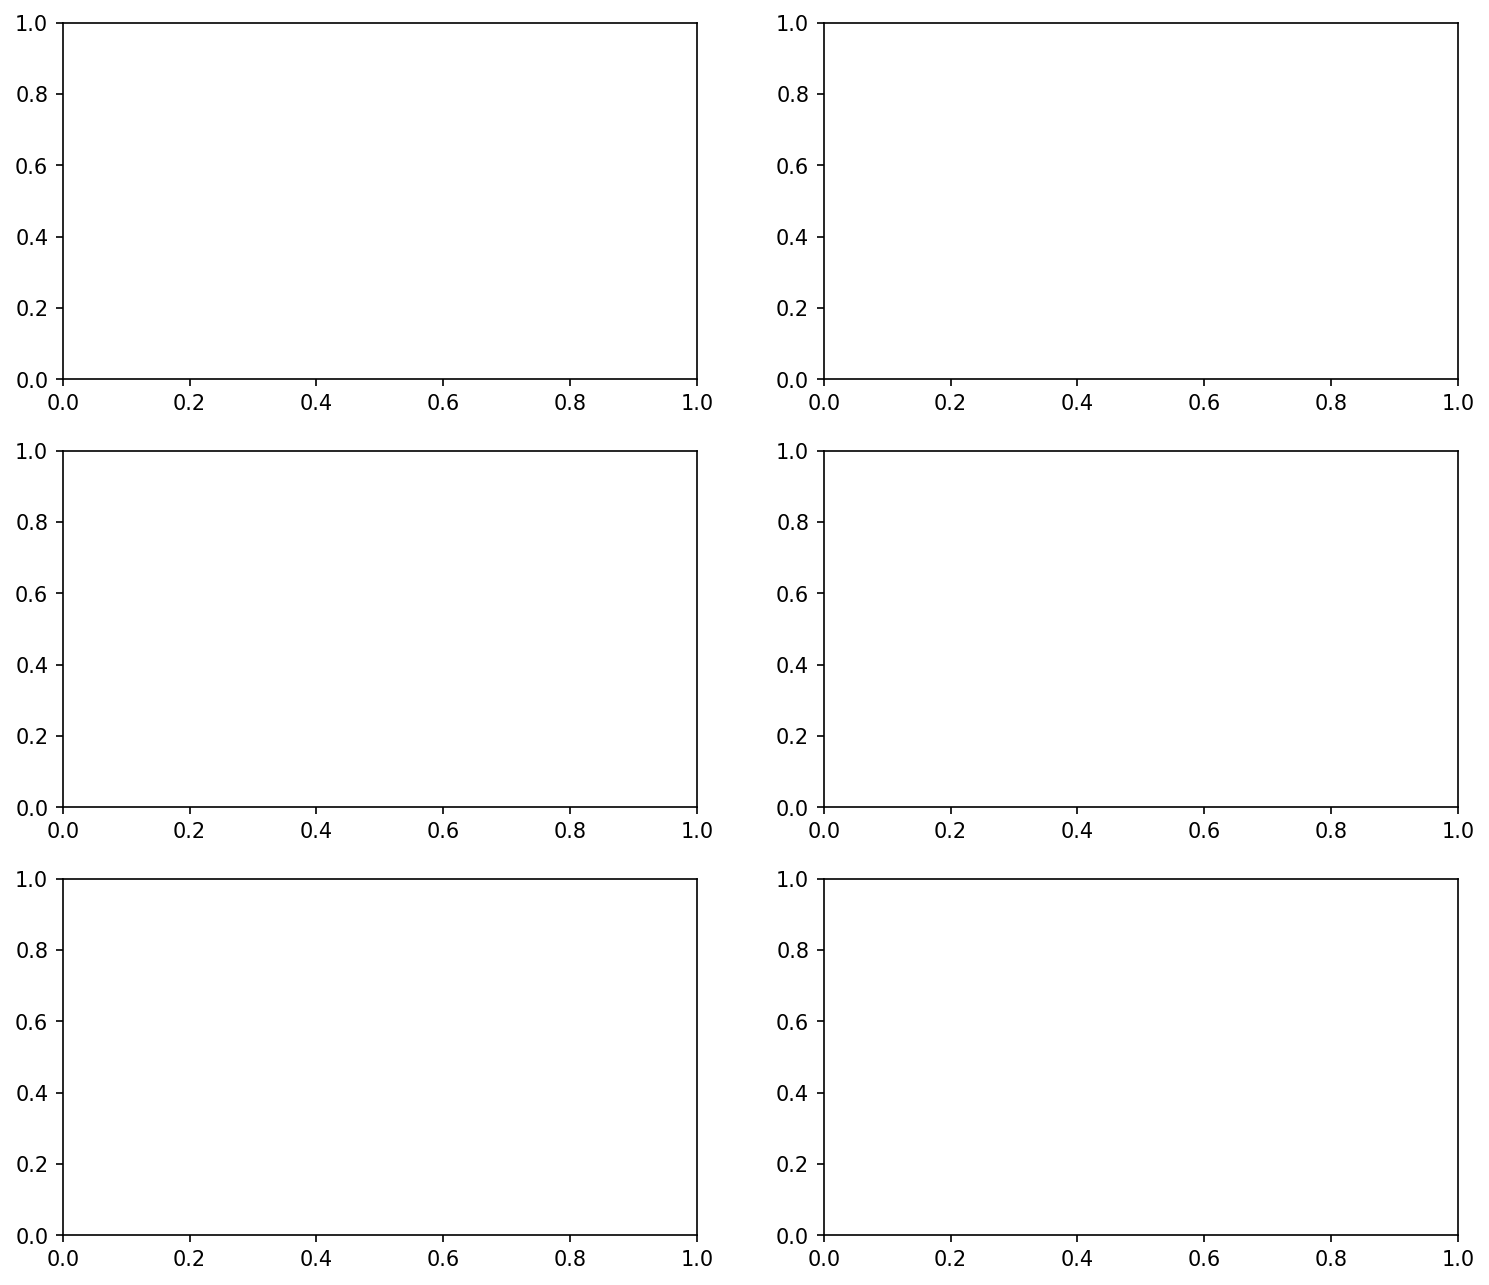

In [4]:
for FW in avail_fw:
    print(f'\n{"=" * 60}')
    print(f'{FW}')
    print(f'{"=" * 60}')

    # Conditions: (label, train_fn, test_fn)
    # train_fn/test_fn: (h_key, layer) -> (X, y)
    cond_specs = [
        ('Single-turn\n(CV 50/50)',
         lambda hk, ly: prepare_st_dataset(hk, ly),
         None),  # special case: split ST in half
        ('Full-context',
         lambda hk, ly: prepare_dataset(traj, FW, hk, ly, split='train'),
         lambda hk, ly: prepare_dataset(traj, FW, hk, ly, split='test')),
    ]
    if has_nc:
        cond_specs.append(
            ('No-context',
             lambda hk, ly: prepare_dataset(nc, FW, hk, ly, split='train'),
             lambda hk, ly: prepare_dataset(nc, FW, hk, ly, split='test'))
        )

    n_conds = len(cond_specs)
    fig, axes = plt.subplots(n_conds, 2, figsize=(12, 3.5 * n_conds), squeeze=False)

    for row, (cond_label, train_fn, test_fn) in enumerate(cond_specs):
        for col, (h_key, pos_label) in enumerate([('h_inst', 'h_inst'),
                                                   ('h_post', 'h_post')]):
            ax = axes[row, col]
            aucs_lin, aucs_mlp = [], []

            for li in tqdm(VERIFY_LAYERS,
                           desc=f'{cond_label.split(chr(10))[0]} {pos_label}',
                           leave=False):
                if test_fn is None:
                    # Single-turn: split in half (first 50 / last 50 per class)
                    X_all, y_all = train_fn(h_key, li)
                    if X_all is None:
                        aucs_lin.append(np.nan)
                        aucs_mlp.append(np.nan)
                        continue
                    n_h = int(y_all.sum())
                    n_b = len(y_all) - n_h
                    # Split: first half train, second half test within each class
                    tr_idx = np.concatenate([np.arange(n_h // 2),
                                            np.arange(n_h, n_h + n_b // 2)])
                    te_idx = np.concatenate([np.arange(n_h // 2, n_h),
                                            np.arange(n_h + n_b // 2, n_h + n_b)])
                    X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
                    X_te, y_te = X_all[te_idx], y_all[te_idx]
                else:
                    X_tr, y_tr = train_fn(h_key, li)
                    X_te, y_te = test_fn(h_key, li)

                aucs_lin.append(train_and_eval(X_tr, y_tr, X_te, y_te, 'linear'))
                aucs_mlp.append(train_and_eval(X_tr, y_tr, X_te, y_te, 'mlp'))

            ax.plot(range(N_VERIFY), aucs_lin, 'o-', color='#1f77b4',
                    lw=2, ms=5, label='Linear (LogReg)')
            ax.plot(range(N_VERIFY), aucs_mlp, 's-', color='#d62728',
                    lw=2, ms=5, label='MLP (64)')

            # Shade the gap
            ax.fill_between(range(N_VERIFY), aucs_lin, aucs_mlp,
                            alpha=0.1, color='#d62728')

            ax.set_xticks(range(N_VERIFY))
            ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
            ax.set_ylabel('AUROC')
            ax.set_ylim(0.45, 1.02)
            ax.axhline(0.5, color='gray', ls=':', lw=0.8)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
            if col == 0:
                ax.set_ylabel(f'{cond_label}\nAUROC')
            if row == 0:
                ax.set_title(pos_label)

    fig.suptitle(f'Linear vs MLP: in-condition AUROC ({FW})', y=1.01, fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'10_fig1_linear_vs_mlp_{FW}.png')
    plt.show()
    print(f'Saved: 10_fig1_linear_vs_mlp_{FW}.png')

## 2. Cross-condition transfer matrix

Train on one condition, test on another. 3×3 matrix
(single-turn, full-context, no-context) for both linear and MLP.

Key comparisons:
- **ST → Full-context**: Can a single-turn detector work on multi-turn?
  If MLP succeeds where linear fails → displacement is a linear rotation.
  If both fail → deeper structural change.
- **Full-context → No-context**: Does multi-turn probe generalize without context?
- **Diagonal**: In-condition upper bound.


actorattack — cross-condition transfer at L20


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
 

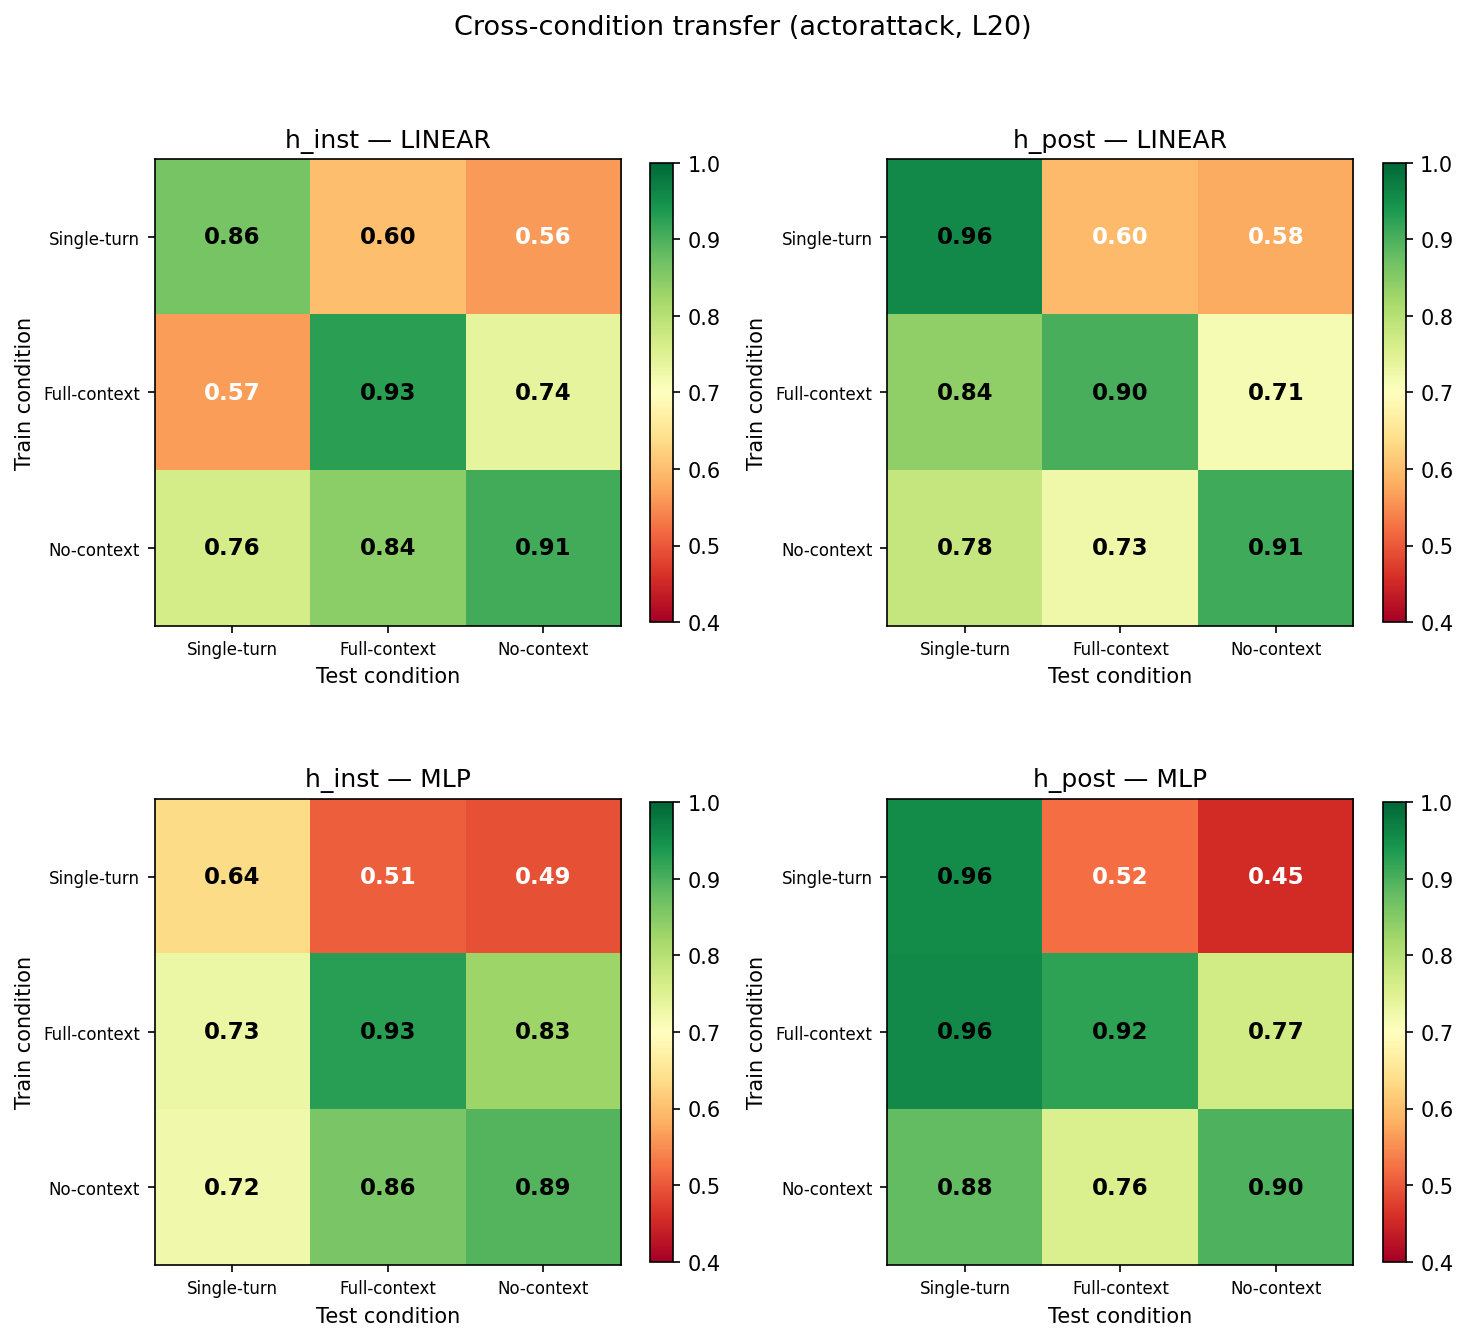

Saved: 10_fig2_cross_condition_actorattack.png

crescendo — cross-condition transfer at L20


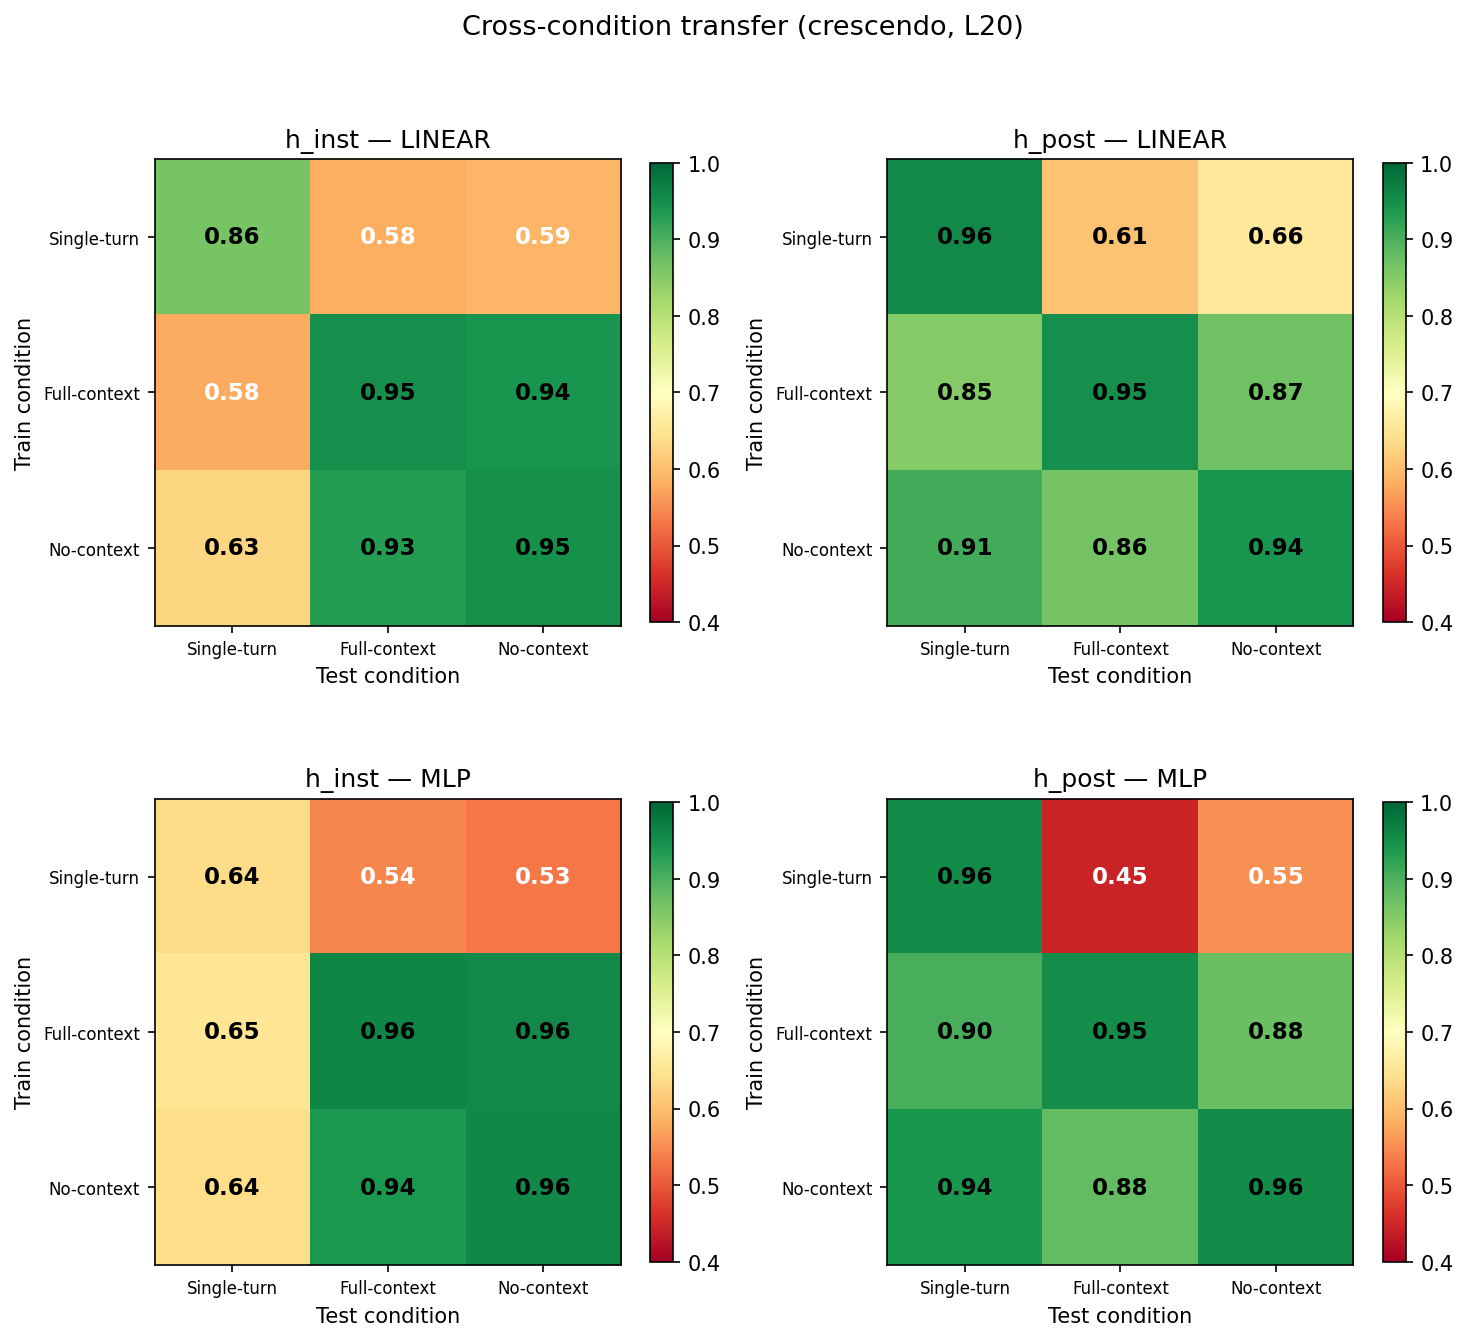

Saved: 10_fig2_cross_condition_crescendo.png

xteaming — cross-condition transfer at L20


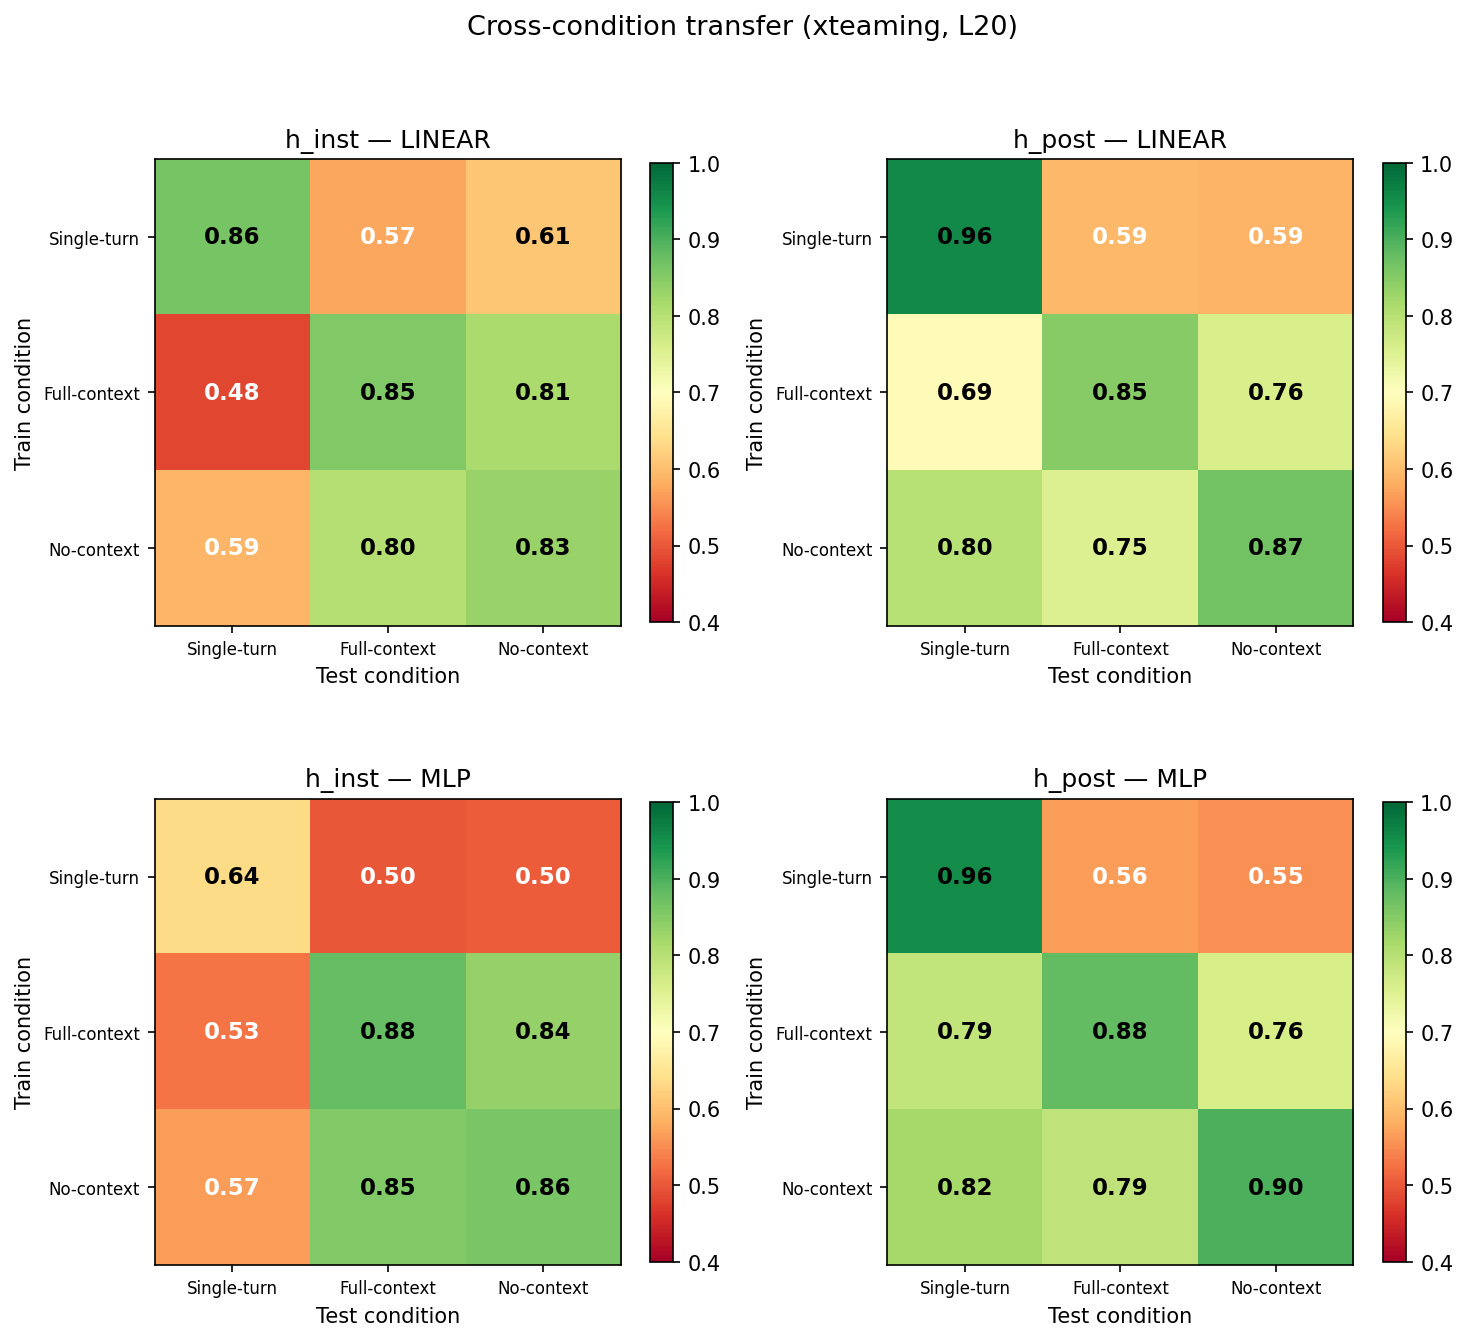

Saved: 10_fig2_cross_condition_xteaming.png


In [5]:
# Use a fixed mid-layer for the transfer matrix
TRANSFER_LAYER = 19  # L20
TRANSFER_LABEL = 'L20'

for FW in avail_fw:
    print(f'\n{"=" * 60}')
    print(f'{FW} — cross-condition transfer at {TRANSFER_LABEL}')
    print(f'{"=" * 60}')

    # Prepare datasets for each condition
    cond_names = ['Single-turn', 'Full-context']
    cond_data = {}  # cond_name -> {'train': (X,y), 'test': (X,y)}

    for h_key in ['h_inst', 'h_post']:
        cond_data[h_key] = {}

        # Single-turn: split 50/50
        X_all, y_all = prepare_st_dataset(h_key, TRANSFER_LAYER)
        n_h = int(y_all.sum())
        n_b = len(y_all) - n_h
        tr_idx = np.concatenate([np.arange(n_h // 2),
                                np.arange(n_h, n_h + n_b // 2)])
        te_idx = np.concatenate([np.arange(n_h // 2, n_h),
                                np.arange(n_h + n_b // 2, n_h + n_b)])
        cond_data[h_key]['Single-turn'] = {
            'train': (X_all[tr_idx], y_all[tr_idx]),
            'test':  (X_all[te_idx], y_all[te_idx]),
        }

        # Full-context
        X_tr, y_tr = prepare_dataset(traj, FW, h_key, TRANSFER_LAYER, 'train')
        X_te, y_te = prepare_dataset(traj, FW, h_key, TRANSFER_LAYER, 'test')
        cond_data[h_key]['Full-context'] = {'train': (X_tr, y_tr), 'test': (X_te, y_te)}

        # No-context
        if has_nc and (FW, 'harmful') in nc:
            X_tr, y_tr = prepare_dataset(nc, FW, h_key, TRANSFER_LAYER, 'train')
            X_te, y_te = prepare_dataset(nc, FW, h_key, TRANSFER_LAYER, 'test')
            cond_data[h_key]['No-context'] = {'train': (X_tr, y_tr), 'test': (X_te, y_te)}
            if 'No-context' not in cond_names:
                cond_names.append('No-context')

    n_c = len(cond_names)
    fig, axes = plt.subplots(2, 2, figsize=(5 * 2, 4.5 * 2))

    for col, (h_key, pos_label) in enumerate([('h_inst', 'h_inst'),
                                               ('h_post', 'h_post')]):
        for row, model_type in enumerate(['linear', 'mlp']):
            ax = axes[row, col]
            mat = np.full((n_c, n_c), np.nan)

            for i, c_train in enumerate(cond_names):
                for j, c_test in enumerate(cond_names):
                    X_tr, y_tr = cond_data[h_key][c_train]['train']
                    X_te, y_te = cond_data[h_key][c_test]['test']
                    mat[i, j] = train_and_eval(X_tr, y_tr, X_te, y_te, model_type)

            im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0)
            ax.set_xticks(range(n_c))
            ax.set_xticklabels(cond_names, fontsize=8)
            ax.set_yticks(range(n_c))
            ax.set_yticklabels(cond_names, fontsize=8)
            ax.set_xlabel('Test condition')
            ax.set_ylabel('Train condition')
            ax.set_title(f'{pos_label} — {model_type.upper()}')
            for i in range(n_c):
                for j in range(n_c):
                    v = mat[i, j]
                    if not np.isnan(v):
                        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                                fontsize=11, fontweight='bold',
                                color='white' if v < 0.6 else 'black')
            plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f'Cross-condition transfer ({FW}, {TRANSFER_LABEL})', y=1.01, fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'10_fig2_cross_condition_{FW}.png')
    plt.show()
    print(f'Saved: 10_fig2_cross_condition_{FW}.png')

## 3. Per-turn transfer heatmap (slowest)

Train MLP at turn k_train, test at turn k_test. The k×k heatmap shows
whether the nonlinear representation is stable across turns.

- **High on diagonal**: per-turn probe works at its own turn
- **High off-diagonal**: representation is stable (probe transfers across turns)
- **Low off-diagonal**: representation changes turn-by-turn even nonlinearly

Compare with the cosine displacement from nb08: if cosine drops but MLP transfer
holds, the displacement is a linear rotation that nonlinear probes see through.


actorattack — per-turn transfer at L20
  k=7: insufficient data, skipping
  k=8: insufficient data, skipping
  Valid turns: [1, 2, 3, 4, 5, 6]


Turn transfer (actorattack):   0%|          | 0/72 [00:00<?, ?it/s]/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Turn transfer (actorattack):   1%|▏         | 1/72 [00:00<00:31,  2.22it/s]/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS RE

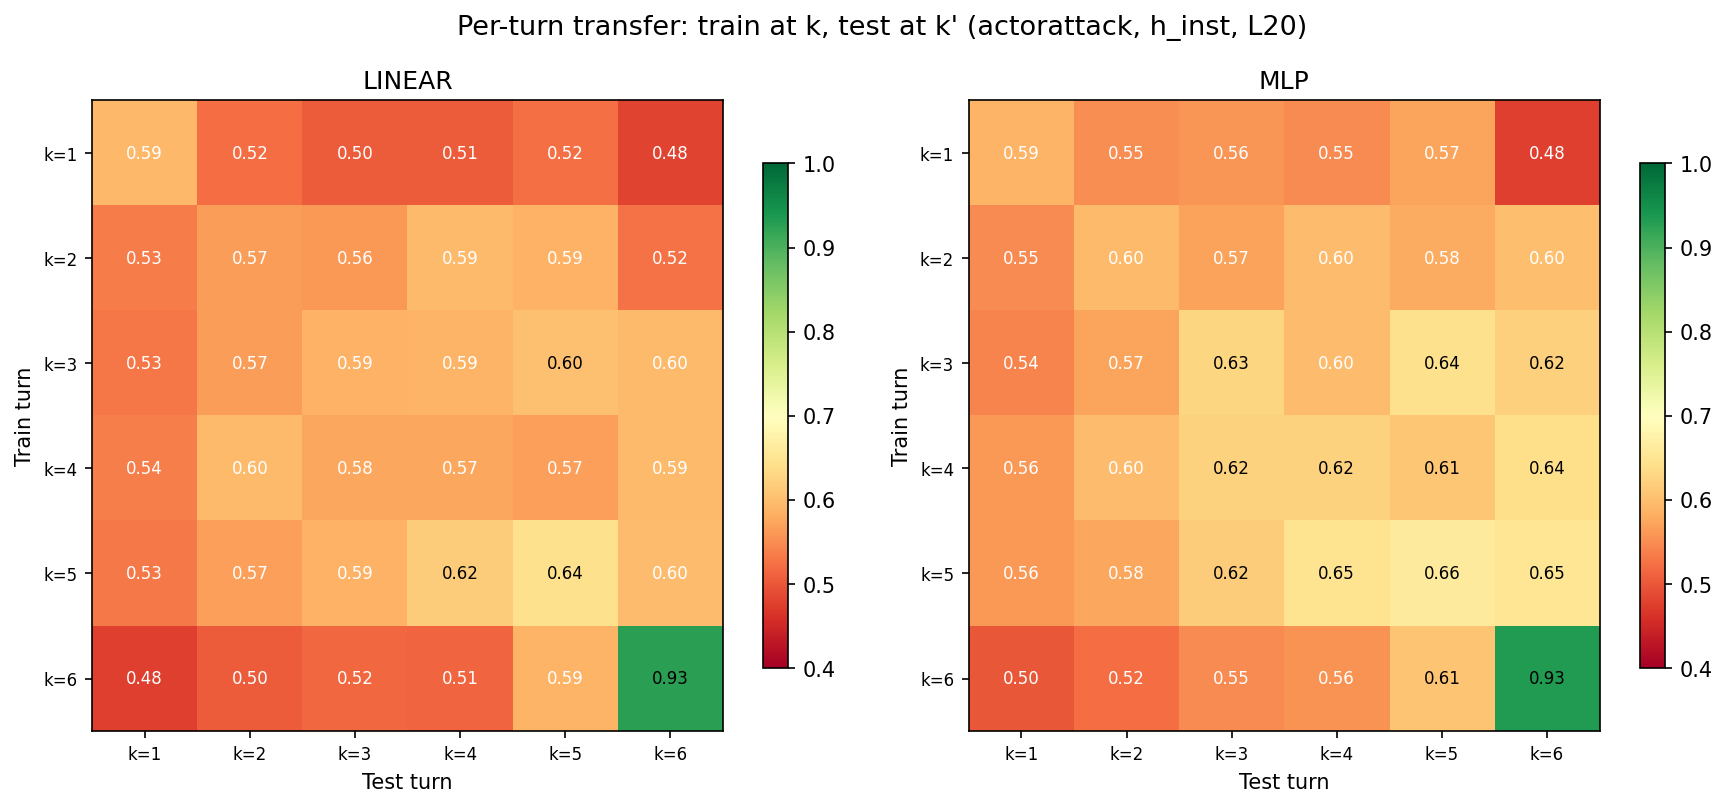

Saved: 10_fig3_turn_transfer_actorattack.png

crescendo — per-turn transfer at L20
  Valid turns: [1, 2, 3, 4, 5, 6, 7, 8]


Turn transfer (crescendo): 100%|██████████| 128/128 [00:27<00:00,  4.73it/s]


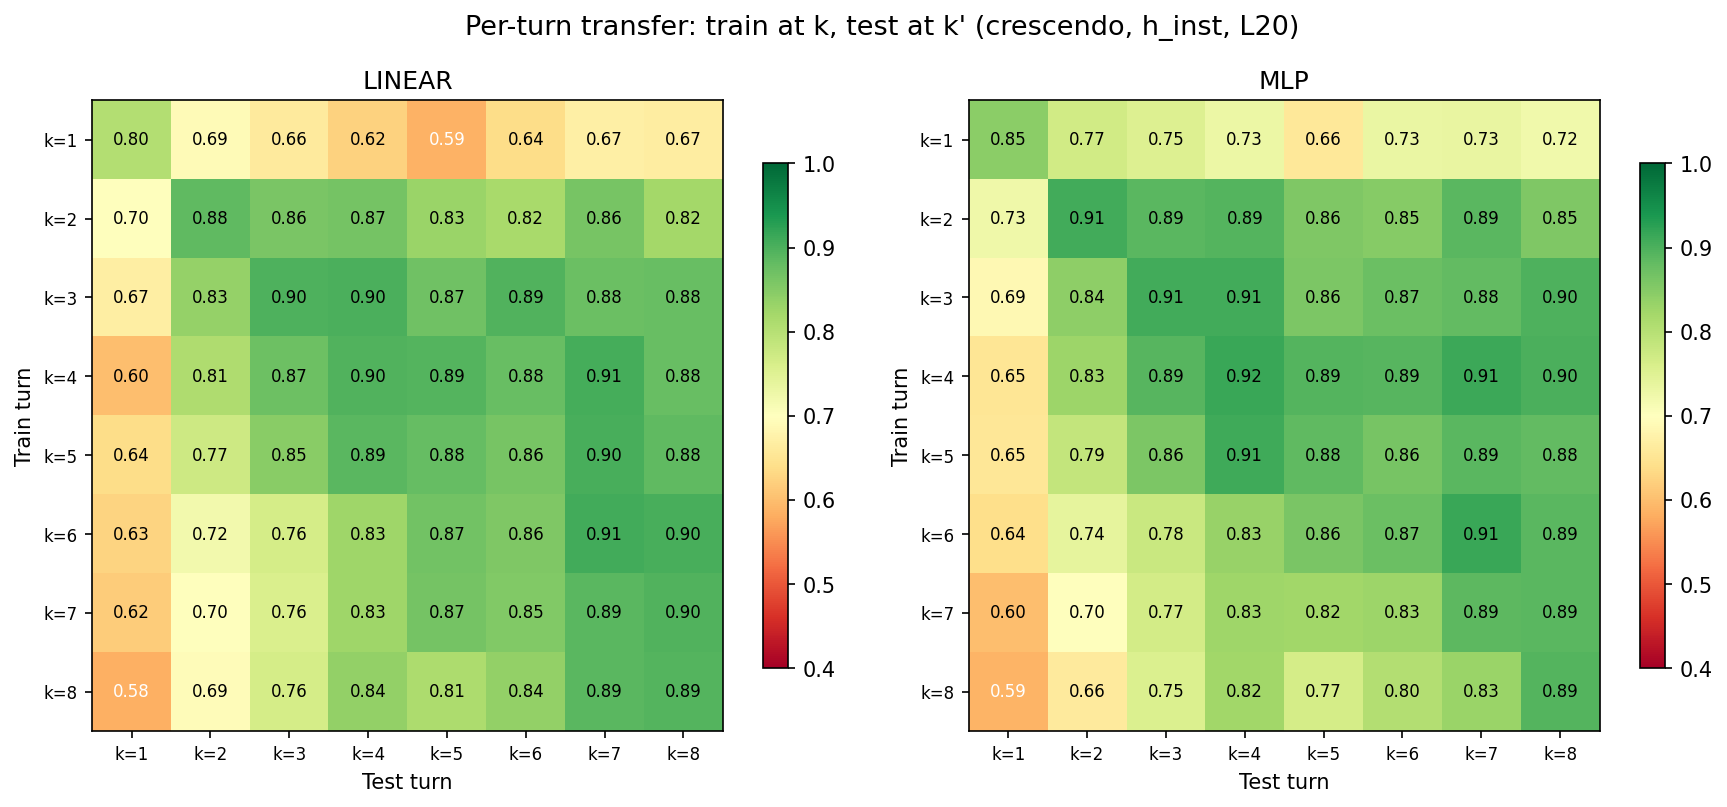

Saved: 10_fig3_turn_transfer_crescendo.png

xteaming — per-turn transfer at L20
  k=6: insufficient data, skipping
  k=7: insufficient data, skipping
  k=8: insufficient data, skipping
  Valid turns: [1, 2, 3, 4, 5]


Turn transfer (xteaming): 100%|██████████| 50/50 [00:11<00:00,  4.28it/s]


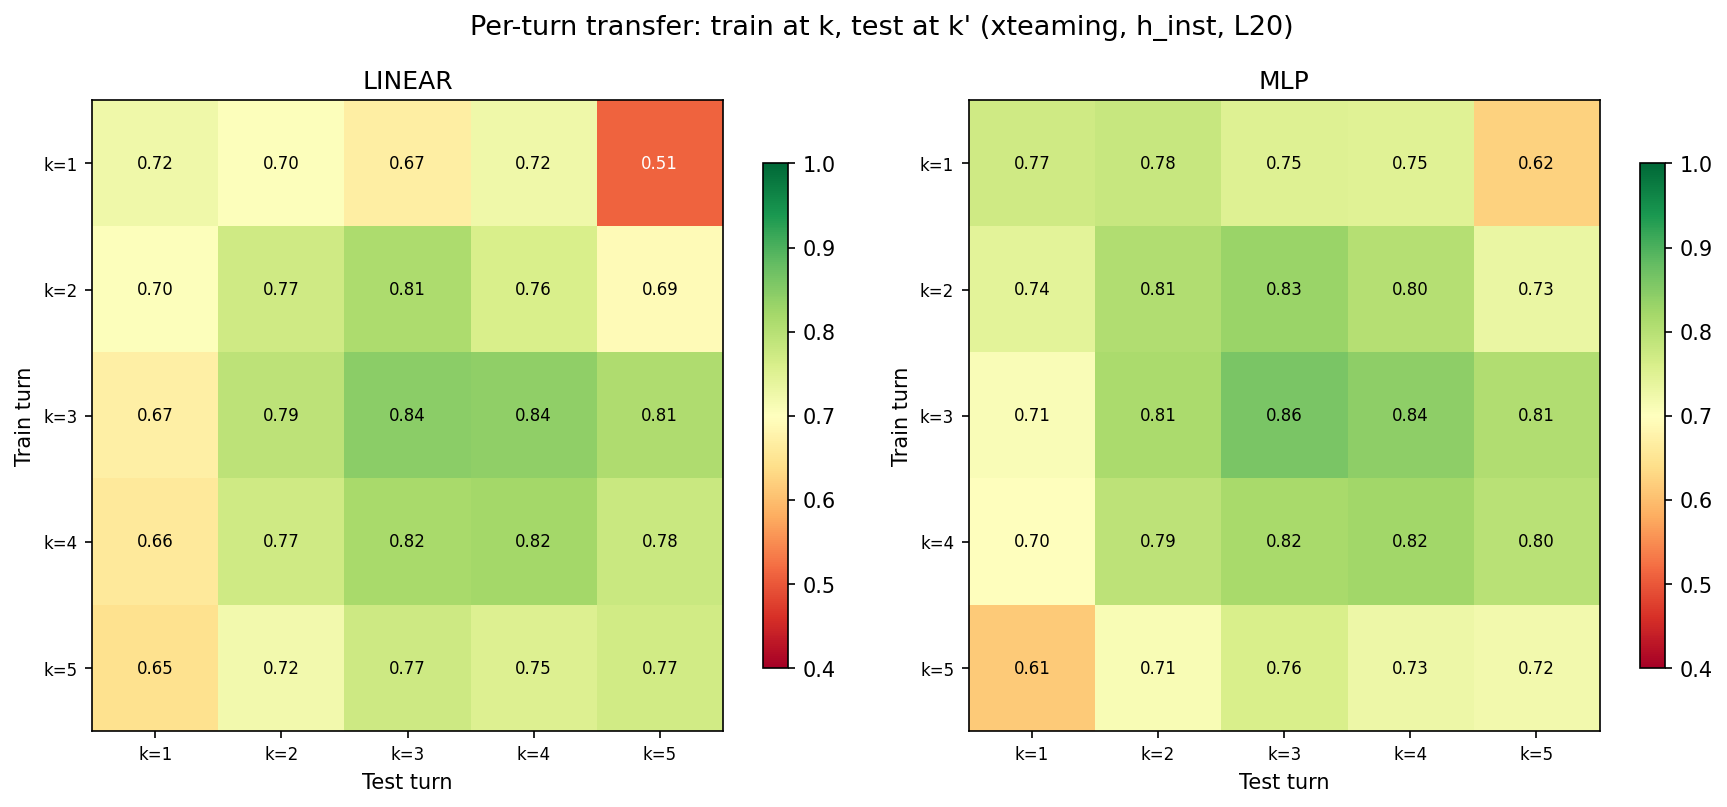

Saved: 10_fig3_turn_transfer_xteaming.png


In [6]:
TURN_LAYER = 19  # L20
TURN_LABEL = 'L20'
TURN_MAX_K = 8   # limit to turns with enough data

for FW in avail_fw:
    print(f'\n{FW} — per-turn transfer at {TURN_LABEL}')

    # Precompute train/test datasets for each turn k
    turn_data = {}  # k -> {'train': (X, y), 'test': (X, y)}
    valid_ks = []

    for k in range(1, TURN_MAX_K + 1):
        X_tr, y_tr = prepare_dataset(traj, FW, 'h_inst', TURN_LAYER, 'train', turn_k=k)
        X_te, y_te = prepare_dataset(traj, FW, 'h_inst', TURN_LAYER, 'test', turn_k=k)
        if X_tr is not None and X_te is not None:
            turn_data[k] = {'train': (X_tr, y_tr), 'test': (X_te, y_te)}
            valid_ks.append(k)
        else:
            print(f'  k={k}: insufficient data, skipping')

    n_k = len(valid_ks)
    if n_k < 3:
        print(f'  Only {n_k} valid turns, skipping framework')
        continue

    print(f'  Valid turns: {valid_ks}')

    # Compute transfer matrices for both linear and MLP
    total = n_k * n_k * 2
    pbar = tqdm(total=total, desc=f'Turn transfer ({FW})')

    mats = {}
    for model_type in ['linear', 'mlp']:
        mat = np.full((n_k, n_k), np.nan)
        for i, k_train in enumerate(valid_ks):
            X_tr, y_tr = turn_data[k_train]['train']
            for j, k_test in enumerate(valid_ks):
                X_te, y_te = turn_data[k_test]['test']
                mat[i, j] = train_and_eval(X_tr, y_tr, X_te, y_te, model_type)
                pbar.update(1)
        mats[model_type] = mat

    pbar.close()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax_idx, model_type in enumerate(['linear', 'mlp']):
        ax = axes[ax_idx]
        mat = mats[model_type]
        im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0)
        ax.set_xticks(range(n_k))
        ax.set_xticklabels([f'k={k}' for k in valid_ks], fontsize=8)
        ax.set_yticks(range(n_k))
        ax.set_yticklabels([f'k={k}' for k in valid_ks], fontsize=8)
        ax.set_xlabel('Test turn')
        ax.set_ylabel('Train turn')
        ax.set_title(f'{model_type.upper()}')
        for i in range(n_k):
            for j in range(n_k):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=8, color='white' if v < 0.6 else 'black')
        plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f'Per-turn transfer: train at k, test at k\' ({FW}, h_inst, {TURN_LABEL})',
                 y=1.02, fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'10_fig3_turn_transfer_{FW}.png')
    plt.show()
    print(f'Saved: 10_fig3_turn_transfer_{FW}.png')